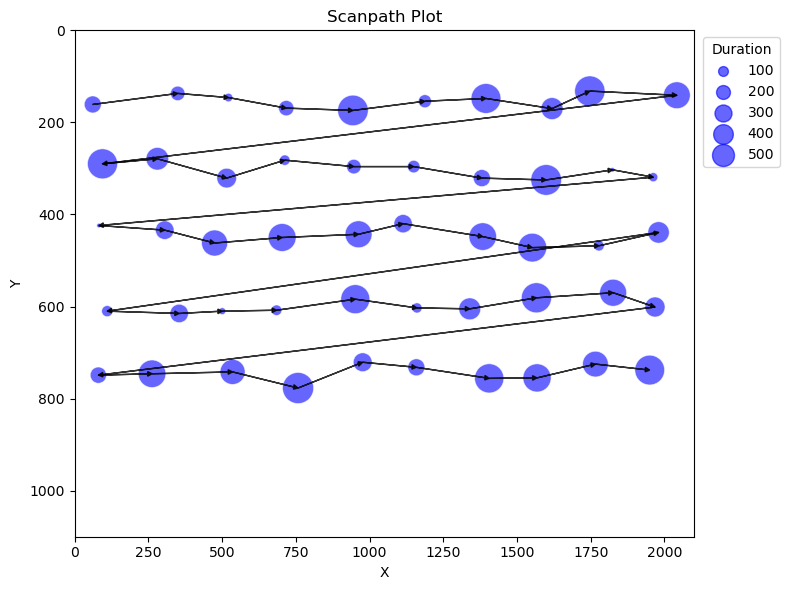

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_scanpaths_2d_single_trial(
    df, x_col, y_col, duration_col, x_limits=None, y_limits=None
):
    """
    Create a 2D scanpath plot for a single trial.

    Parameters:
    - df: DataFrame containing the data.
    - x_col: Column for the X-axis values.
    - y_col: Column for the Y-axis values.
    - duration_col: Column for the point sizes based on duration.
    - x_limits: Tuple specifying (min, max) limits for the X-axis.
    - y_limits: Tuple specifying (min, max) limits for the Y-axis.
    """
    plt.figure(figsize=(8, 6))

    # Plot scatter points
    sns.scatterplot(
        x=x_col,
        y=y_col,
        size=duration_col,
        data=df,
        alpha=0.6,
        color="blue",
        sizes=(10, 500),
        legend=False,
    )

    # Plot lines with arrows connecting points
    for i in range(len(df) - 1):
        plt.arrow(
            df.iloc[i][x_col],
            df.iloc[i][y_col],
            df.iloc[i + 1][x_col] - df.iloc[i][x_col],
            df.iloc[i + 1][y_col] - df.iloc[i][y_col],
            head_width=10,
            head_length=15,
            fc="black",
            ec="black",
            linewidth=1,
            alpha=0.8,
            length_includes_head=True,
        )

    # Create a custom legend for duration
    for size in [100, 200, 300, 400, 500]:
        plt.scatter([], [], s=size * 0.5, alpha=0.6, color="blue", label=f"{size}")

    plt.legend(title="Duration", loc="upper right", bbox_to_anchor=(1.15, 1))

    # Set axis limits if provided
    if x_limits:
        plt.xlim(x_limits)
    if y_limits:
        plt.ylim(y_limits)

    # Customize plot
    plt.gca().invert_yaxis()  # Invert Y-axis for top-down view
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Scanpath Plot")
    plt.tight_layout()


# Example data
# Create base patterns
x_base = np.linspace(100, 2000, 10)  # 10 points from 100 to 2000
x_with_noise = np.array(
    [x + np.random.randint(-50, 50) for x in np.tile(x_base, 5)]
)  # Repeat 5 times with noise

y_levels = np.array([150, 300, 450, 600, 750])  # 5 different y levels
y_with_noise = np.array(
    [y + np.random.randint(-30, 30) for y in np.repeat(y_levels, 10)]
)  # Each level repeated 10 times

data = {
    "x": x_with_noise,
    "y": y_with_noise,
    "duration": np.random.randint(
        100, 500, 50
    ),  # Keep the original duration generation
}

df = pd.DataFrame(data)

# Plot for single trial
plot_scanpaths_2d_single_trial(
    df,
    x_col="x",
    y_col="y",
    duration_col="duration",
    x_limits=(0, 2100),
    y_limits=(0, 1100),
)
plt.show()